In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings as ws
ws.filterwarnings('ignore')

In [2]:
stock = pd.read_csv(r"C:\Users\BCS\OneDrive\Documents\pyfinal.csv")
stock.head(5)

,DATE,SERIES,OPEN,HIGH,LOW,PREV. CLOSE,LTP,CLOSE,VWAP,52W H,52W L,VOLUME,VALUE,NO. OF TRADES
0,1-Dec-25,EQ,272.45,272.45,268.75,269.95,269.90,269.65,270.04,336.25,247.3,10428760,"2,81,62,31,287.95",130049
1,28-Nov-25,EQ,273.80,274.35,269.45,273.70,270.00,269.95,270.75,345.40,247.3,12580231,"3,40,60,79,261.85",92273
2,27-Nov-25,EQ,277.00,277.00,273.30,275.05,273.95,273.70,274.30,345.40,247.3,9865039,"2,70,59,71,497.90",98121
3,26-Nov-25,EQ,274.00,276.95,273.50,273.45,274.40,275.05,275.02,345.40,247.3,8352869,"2,29,72,08,061.60",68826
4,25-Nov-25,EQ,275.00,276.90,272.65,275.80,272.65,273.45,274.42,345.40,247.3,12114606,"3,32,44,41,144.55",96719


In [3]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1472 entries, 0 to 1471
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE            1472 non-null   object 
 1   SERIES          1472 non-null   object 
 2   OPEN            1472 non-null   float64
 3   HIGH            1472 non-null   float64
 4   LOW             1472 non-null   float64
 5   PREV. CLOSE     1472 non-null   float64
 6   LTP             1472 non-null   float64
 7   CLOSE           1472 non-null   float64
 8   VWAP            1472 non-null   float64
 9   52W H           1472 non-null   float64
 10  52W L           1472 non-null   float64
 11  VOLUME          1472 non-null   int64  
 12  VALUE           1472 non-null   object 
 13  NO. OF  TRADES  1472 non-null   int64  
dtypes: float64(9), int64(2), object(3)
memory usage: 161.1+ KB


In [4]:
stock.shape

(1472, 14)

In [5]:
stock.isnull().sum()

DATE              0
SERIES            0
OPEN              0
HIGH              0
LOW               0
PREV. CLOSE       0
LTP               0
CLOSE             0
VWAP              0
52W H             0
52W L             0
VOLUME            0
VALUE             0
NO. OF  TRADES    0
dtype: int64

In [6]:
stock.columns

Index(['DATE', 'SERIES', 'OPEN', 'HIGH', 'LOW', 'PREV. CLOSE', 'LTP', 'CLOSE',
       'VWAP', '52W H', '52W L', 'VOLUME', 'VALUE', 'NO. OF  TRADES'],
      dtype='object')

In [7]:
stock["DATE"] = pd.to_datetime(stock["DATE"])

In [8]:
stock.dtypes

DATE              datetime64[ns]
SERIES                    object
OPEN                     float64
HIGH                     float64
LOW                      float64
PREV. CLOSE              float64
LTP                      float64
CLOSE                    float64
VWAP                     float64
52W H                    float64
52W L                    float64
VOLUME                     int64
VALUE                     object
NO. OF  TRADES             int64
dtype: object

In [9]:
stock['VALUE'] = stock['VALUE'].str.replace(",","").astype(float)

In [10]:
stock.columns = stock.columns.str.replace(" ","_").str.replace(".","")
print(stock.columns)

Index(['DATE', 'SERIES', 'OPEN', 'HIGH', 'LOW', 'PREV_CLOSE', 'LTP', 'CLOSE',
       'VWAP', '52W_H', '52W_L', 'VOLUME', 'VALUE', 'NO_OF__TRADES'],
      dtype='object')


In [11]:
print("Duplicated ",stock.duplicated().sum())

Duplicated  0


In [12]:
stock.describe()

,DATE,OPEN,HIGH,LOW,PREV_CLOSE,LTP,CLOSE,VWAP,52W_H,52W_L,VOLUME,VALUE,NO_OF__TRADES
count,1472,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1472.000000,1.472000e+03,1.472000e+03,1472.000000
mean,2022-12-13 22:54:27.391304192,236.678431,239.573675,233.699389,236.520686,236.611345,236.597996,236.627052,275.076970,179.609001,1.310213e+07,3.146970e+09,92351.553668
min,2020-01-01 00:00:00,141.550000,151.900000,122.150000,144.150000,147.450000,144.150000,146.370000,191.850000,122.150000,3.982910e+05,1.150080e+08,1.000000
25%,2021-06-24 18:00:00,199.950000,202.400000,197.350000,199.975000,200.125000,200.212500,199.957500,248.350000,154.600000,7.616822e+06,1.659571e+09,58444.250000
50%,2022-12-07 12:00:00,225.100000,228.325000,223.425000,225.225000,225.550000,225.350000,225.745000,251.500000,186.350000,1.058895e+07,2.467868e+09,78919.000000
75%,2024-06-06 06:00:00,281.125000,284.350000,277.700000,280.275000,280.962500,280.275000,280.952500,345.400000,190.650000,1.521431e+07,3.848992e+09,113133.750000
max,2025-12-01 00:00:00,364.050000,366.250000,357.200000,365.450000,364.900000,365.450000,362.240000,366.250000,257.650000,1.271584e+08,2.563887e+10,579864.000000
std,NaN,50.210781,50.557225,49.719017,50.176392,50.173852,50.163106,50.146746,54.659684,37.658766,9.653928e+06,2.432438e+09,53579.994468


In [13]:
print("mean of closing price ",stock['CLOSE'].mean())
print("Maximum Closing price",stock['CLOSE'].max())
print("Minimum Closing price",stock['CLOSE'].min())

mean of closing price  236.59799592391303
Maximum Closing price 365.45
Minimum Closing price 144.15


In [14]:
# maximum rise
stock['daily_change'] = stock['CLOSE'] - stock['OPEN']
stock.nlargest(1, 'daily_change')[['DATE', 'daily_change']]

,DATE,daily_change
260,2024-11-11,16.25


In [15]:
# minimum down 
stock['daily_change'] = stock['CLOSE'] - stock['OPEN']
stock.nsmallest(1, 'daily_change')[['DATE', 'daily_change']]

,DATE,daily_change
370,2024-06-04,-39.0


In [37]:
# daily return maximum and minimum
stock['Daily_return'] = ((stock['CLOSE']-stock['PREV_CLOSE'])/stock['PREV_CLOSE'])*100


print("Maximum Daily Return:")
print("Date:", max_row['DATE'])
print("Return:", max_row['Daily_return'])

print("------------------------")

# Row where minimum return happened
min_row = stock.loc[stock['Daily_return'].idxmin()]

print("Minimum Daily Return:")
print("Date:", min_row['DATE'])
print("Return:", min_row['Daily_return'])

Maximum Daily Return:
Date: 2022-07-25 00:00:00
Return: 9.460516028146992
------------------------
Minimum Daily Return:
Date: 2023-09-12 00:00:00
Return: -27.674858223062376


In [17]:
# how many days market are bullish and how many are bearish
stock['Market_Direction'] = np.where(stock['Daily_return'] > 0,'Bullish','Bearish')
print(stock['Market_Direction'].value_counts())

Market_Direction
Bullish    740
Bearish    732
Name: count, dtype: int64


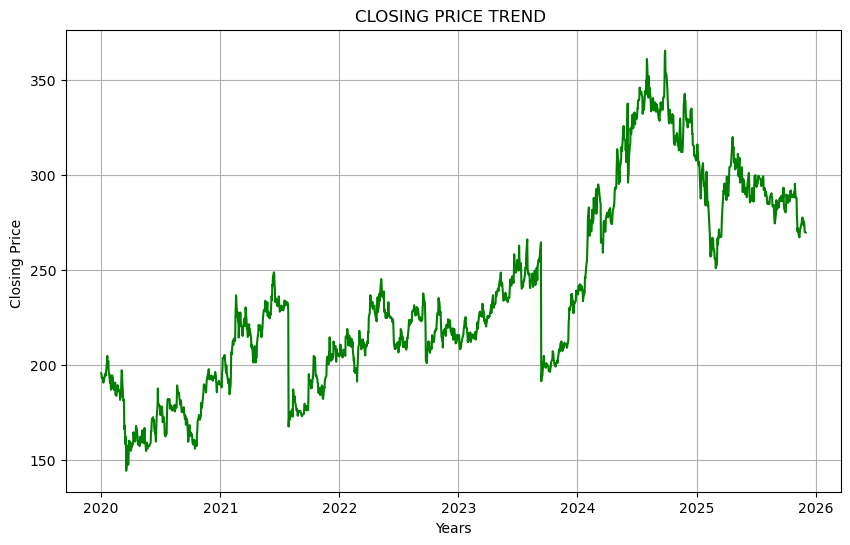

In [18]:
#closing price trend analysis 
plt.figure(figsize=(10,6))
plt.plot(stock['DATE'],stock['CLOSE'],color='green')
plt.xlabel("Years")
plt.ylabel("Closing Price ")
plt.grid(True)
plt.title("CLOSING PRICE TREND ")
plt.show()

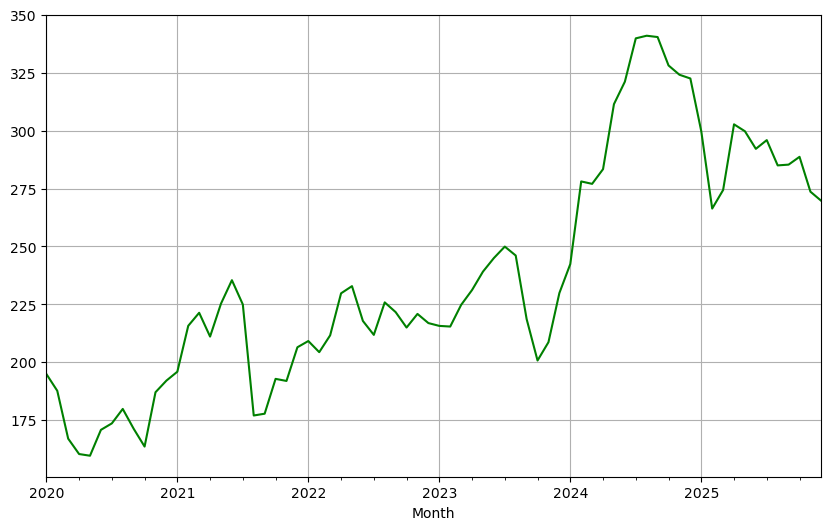

In [19]:
# monthly average clossing price 
stock['Month'] = stock['DATE'].dt.to_period('M')
month_avg = stock.groupby('Month')['CLOSE'].mean()
month_avg.plot(figsize=(10,6),color= 'green')
plt.grid(True)
plt.show()

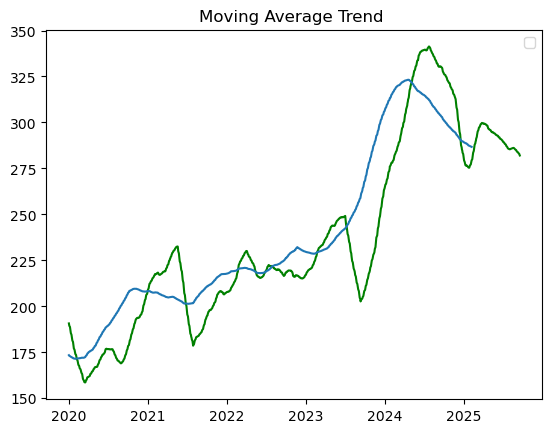

In [20]:
stock['30_ma'] = stock['CLOSE'].rolling(50).mean()
stock['100_ma'] = stock['CLOSE'].rolling(200).mean()
#plt.plot(stock['DATE'],stock['CLOSE'],label = 'Closing price')
plt.legend()
plt.plot(stock['DATE'],stock['30_ma'],label='30 Movvng Average',color='green')
plt.plot(stock['DATE'],stock['100_ma'],label='10_Moving Average')
plt.title('Moving Average Trend ')
plt.show()

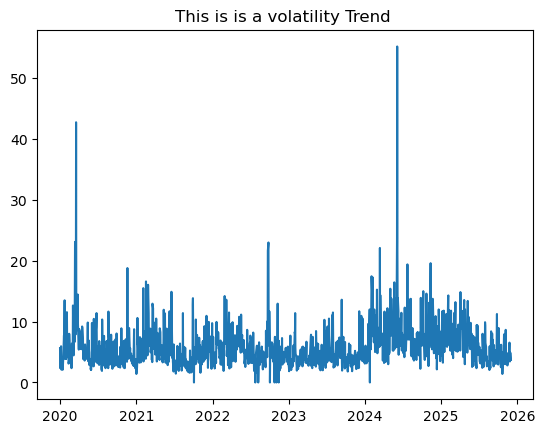

In [21]:
stock['Volatility'] = stock['HIGH'] - stock['LOW']
#print("Highest volatility ",stock['Volatility'].max())
plt.plot(stock['DATE'],stock['Volatility'])
plt.title("This is is a volatility Trend ")
plt.show()

           DATE     VOLUME   CLOSE
1455 2020-01-23  127158366  201.95
789  2022-09-26  125660351  200.85
1416 2020-03-20   73960859  157.25
370  2024-06-04   73262478  295.95
446  2024-02-08   69776717  276.20
1418 2020-03-18   67448864  144.15
974  2021-12-30   65610905  205.35
790  2022-09-23   65372042  202.55
494  2023-11-30   60354322  208.95
676  2023-03-02   59781419  220.35


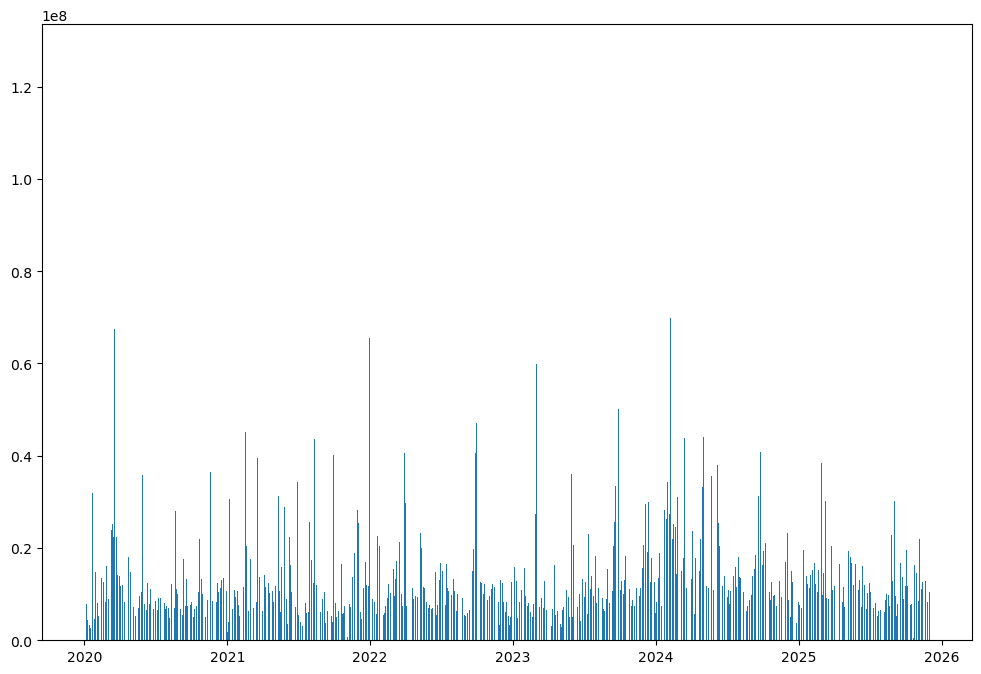

In [22]:
top_volume =stock.sort_values('VOLUME',ascending= False).head(10)
print(top_volume[['DATE','VOLUME','CLOSE']])
plt.figure(figsize=(12,8))
plt.bar(stock['DATE'],stock['VOLUME'])
plt.show()

In [23]:
# this describe the vwap difference
stock['VWAP_diff'] = stock['VWAP'] -  stock['CLOSE']
accumulation = stock[stock["VWAP_diff"] > 0]
print("Accumulation Days:", len(accumulation))
# i have too work little more on this 

Accumulation Days: 768


In [24]:
# diff between 52 week high and close
stock['Difference'] = ((stock['52W_H']-stock['CLOSE'])/stock['52W_H'])*100
latest = stock.iloc[0]
print("Latest CLOSE",latest['CLOSE'])
print("Latest 52 week high",latest['52W_H'])
print("Latest 52 week LOW",latest['52W_L'])

Latest CLOSE 269.65
Latest 52 week high 336.25
Latest 52 week LOW 247.3


In [25]:
corr = stock[["CLOSE","VOLUME","VALUE","VWAP",'NO_OF__TRADES']].corr()
print(corr)

                  CLOSE    VOLUME     VALUE      VWAP  NO_OF__TRADES
CLOSE          1.000000  0.098103  0.381042  0.999588       0.411221
VOLUME         0.098103  1.000000  0.937532  0.096427       0.726323
VALUE          0.381042  0.937532  1.000000  0.379553       0.827158
VWAP           0.999588  0.096427  0.379553  1.000000       0.411072
NO_OF__TRADES  0.411221  0.726323  0.827158  0.411072       1.000000


In [26]:
threshold = stock["VOLUME"].mean() + 3*stock["VOLUME"].std()
outliers = stock[stock["VOLUME"] > threshold]
print("Unusual Volume Days:", outliers.shape[0])

Unusual Volume Days: 22
